In [103]:
# Core
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay


In [104]:
SEED = 0

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Seed set to:", SEED)


Seed set to: 0


In [105]:
with open("training dataset/tabular/engineered_feature_groups.json") as f:
    feature_groups = json.load(f)

phase1_features = (
    feature_groups["Clinical"] +
    feature_groups["Laboratory"] +
    feature_groups["Demographic / Other"] +
    feature_groups["Scoring"] +
    feature_groups["clinical_derived"] +
    feature_groups["lab_derived"]
)

print("Phase 1 feature count:", len(phase1_features))


Phase 1 feature count: 50


In [106]:
train_df = pd.read_csv("training dataset/tabular/train_split.csv")
val_df   = pd.read_csv("training dataset/tabular/val_split.csv")
test_df  = pd.read_csv("training dataset/tabular/test_split.csv")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (546, 103)
Val: (78, 103)
Test: (157, 103)


In [107]:
available_features = [f for f in phase1_features if f in train_df.columns]
print("Final features used:", len(available_features))


Final features used: 50


In [108]:
TARGET = "Diagnosis"

X_train = train_df[available_features]
y_train = train_df[TARGET]

X_val = val_df[available_features]
y_val = val_df[TARGET]

X_test = test_df[available_features]
y_test = test_df[TARGET]

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (546, 50)
Val shape: (78, 50)
Test shape: (157, 50)


In [109]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaled train:", X_train_scaled.shape)
print("Scaled val:", X_val_scaled.shape)
print("Scaled test:", X_test_scaled.shape)


Scaled train: (546, 50)
Scaled val: (78, 50)
Scaled test: (157, 50)


In [110]:
small_mlp = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation="relu", name="clinical_embedding"),
    Dense(1, activation="sigmoid")
])

small_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

small_mlp.summary()


C:\Users\Trinabh Mitra\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_embedding (Dense)      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177 (8.50 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
early_stop = EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

history = small_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3919 - auc: 0.3929 - loss: 0.9830 - val_accuracy: 0.5256 - val_auc: 0.5156 - val_loss: 0.7606
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5055 - auc: 0.5299 - loss: 0.7258 - val_accuracy: 0.6282 - val_auc: 0.6814 - val_loss: 0.6470
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6209 - auc: 0.6666 - loss: 0.6426 - val_accuracy: 0.6410 - val_auc: 0.7089 - val_loss: 0.6062
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6923 - auc: 0.7489 - loss: 0.5864 - val_accuracy: 0.6410 - val_auc: 0.7201 - val_loss: 0.5899
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7216 - auc: 0.7891 - loss: 0.5478 - val_accuracy: 0.6538 - val_auc: 0.7364 - val_loss: 0.5815
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7381 - auc: 0.8040 - loss: 0.5253 - val_accuracy: 0.6795 - val_auc: 0.7449 - val_loss: 0.5740
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

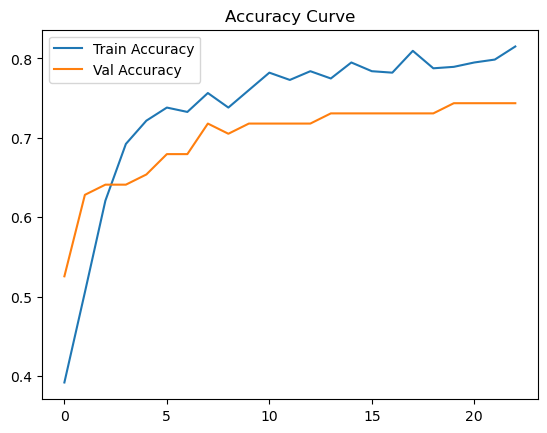

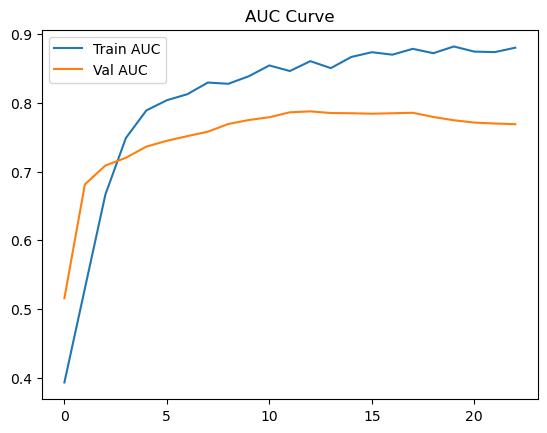

In [112]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC Curve")
plt.show()


In [117]:
val_probs = small_mlp.predict(X_val_scaled).ravel()

thresholds = np.arange(0.61, 0.63, 0.001)
results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    auc = roc_auc_score(y_val, val_probs)
    results.append((t, acc, auc))

results_df = pd.DataFrame(results, columns=["threshold", "accuracy", "auc"])
results_df.sort_values("accuracy", ascending=False)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


,threshold,accuracy,auc
2,0.612,0.756410,0.788043
3,0.613,0.756410,0.788043
4,0.614,0.756410,0.788043
5,0.615,0.756410,0.788043
6,0.616,0.756410,0.788043
7,0.617,0.756410,0.788043
8,0.618,0.756410,0.788043
1,0.611,0.756410,0.788043
10,0.620,0.743590,0.788043
15,0.625,0.743590,0.788043
